### 설정 및 라이브러리 로드

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드 함수 정의

In [2]:
def load_wine_data(file_name):
    if 'white' in file_name:
        df = pd.read_csv(file_name, sep=';')
    else:
        df = pd.read_csv(file_name)
    
    df.columns = df.columns.str.strip()
    # 6점 이상은 고급(1), 나머지는 일반(0)
    df['target'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
    return df

### 시각화 및 학습 통합 함수

In [3]:
def process_wine_ml(file_name, model_output_name):
    print(f"--- [{file_name}] 분석 및 학습 시작 ---")
    df = load_wine_data(file_name)
    
    # 1. 상관관계 분석 (EDA)
    plt.figure(figsize=(10, 7))
    sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt='.2f')
    plt.title(f'{file_name} 성분 상관관계')
    plt.show()

    # 2. 데이터 분할
    X = df.drop(['quality', 'target'], axis=1)
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 3. 모델 학습
    model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    # 4. 특성 중요도 확인
    plt.figure(figsize=(10, 5))
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    sns.barplot(x=importances, y=importances.index, palette='viridis')
    plt.title(f'{file_name} AI 판단 기준 (중요도)')
    plt.show()

    # 5. 모델 저장 (기존에 만든 model 폴더가 있다면 경로 수정 가능)
    # os.makedirs('model', exist_ok=True)
    # joblib.dump(model, f'model/{model_output_name}')
    joblib.dump(model, model_output_name)
    print(f"✅ {model_output_name} 저장 완료!\n")

### 실행

--- [dataset/winequality-red.csv] 분석 및 학습 시작 ---


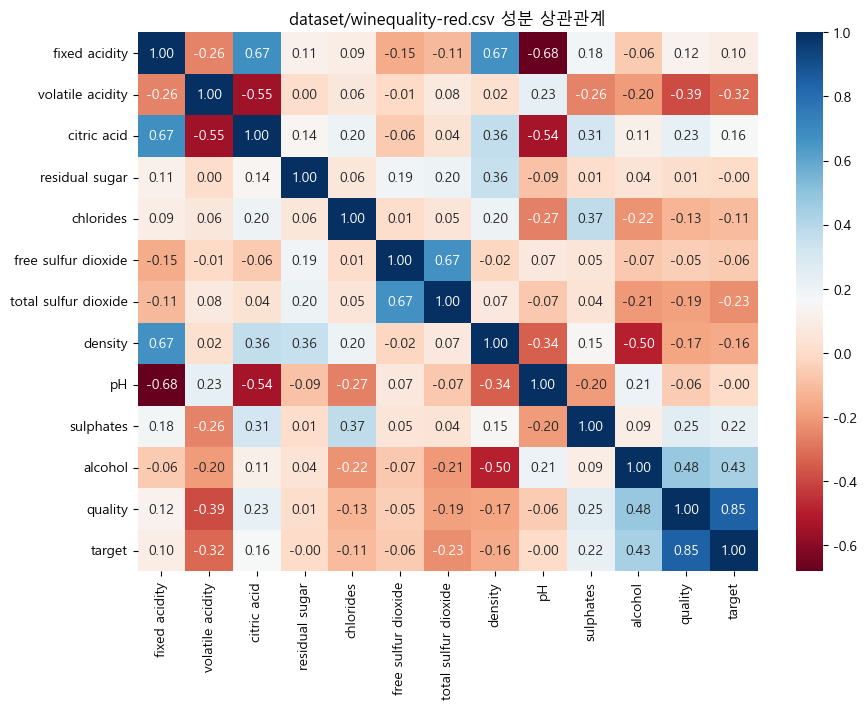

C:\Users\human-18\AppData\Local\Temp\ipykernel_2800\3529082989.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


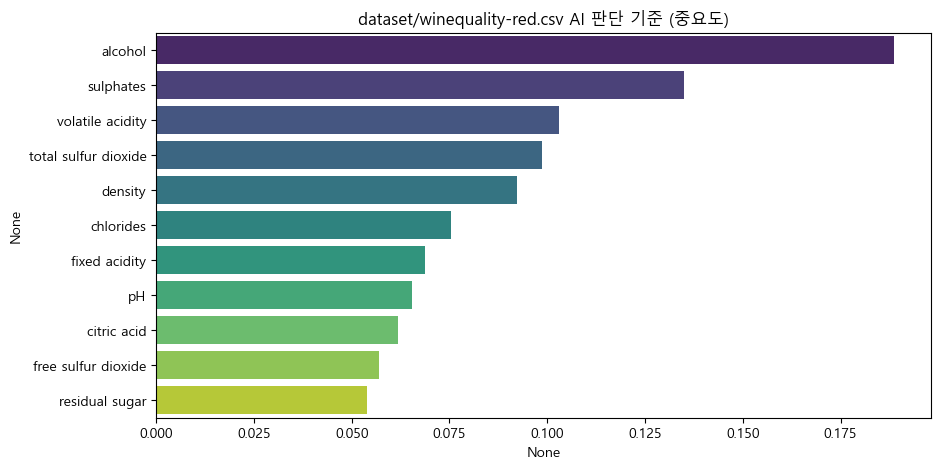

✅ model/red_model.pkl 저장 완료!

--- [dataset/winequality-white.csv] 분석 및 학습 시작 ---


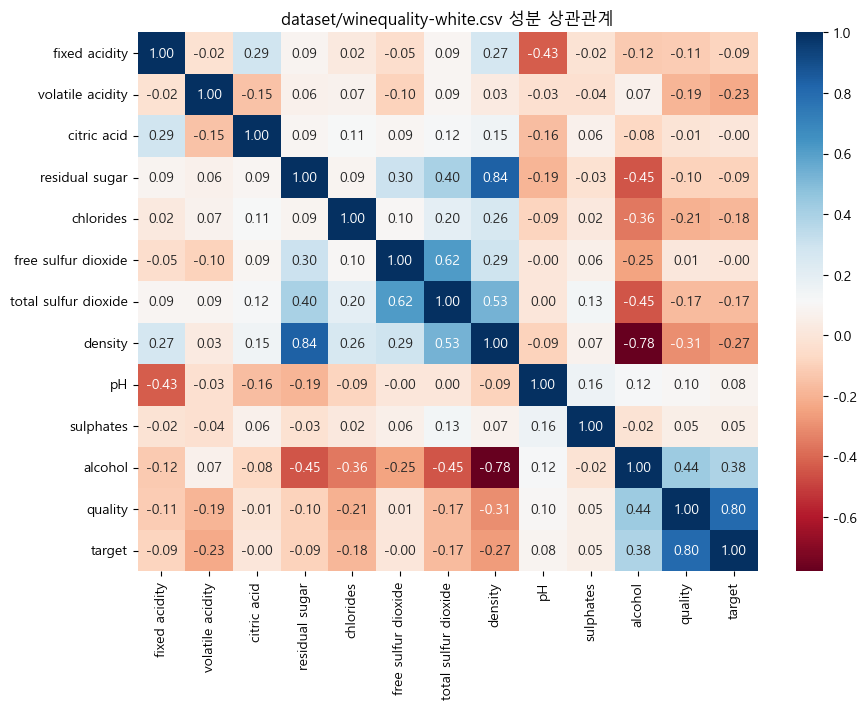

C:\Users\human-18\AppData\Local\Temp\ipykernel_2800\3529082989.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


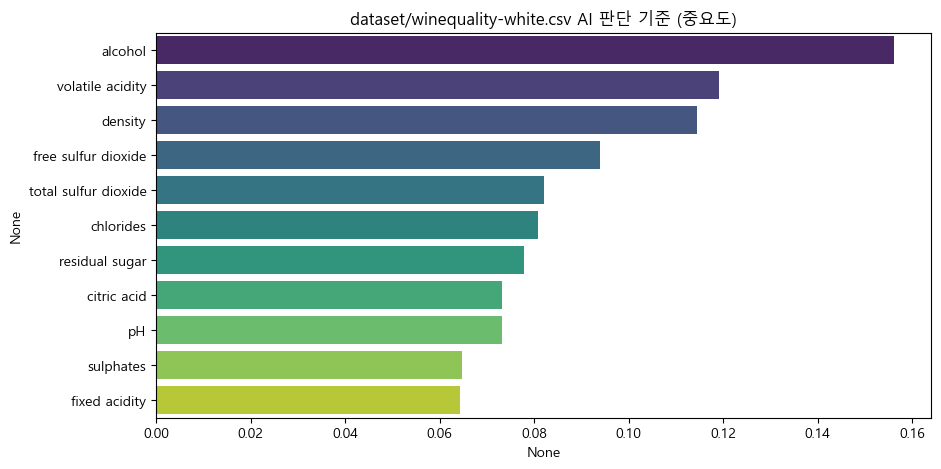

✅ model/white_model.pkl 저장 완료!



In [5]:
# 1. model 폴더가 없다면 자동으로 생성 (오류 방지)
import os
if not os.path.exists('model'):
    os.makedirs('model')
    print("model 폴더를 생성했습니다.")

# 2. 레드 와인 실행 (dataset 폴더에서 읽어서 model 폴더에 저장)
process_wine_ml('dataset/winequality-red.csv', 'model/red_model.pkl')

# 3. 화이트 와인 실행 (dataset 폴더에서 읽어서 model 폴더에 저장)
process_wine_ml('dataset/winequality-white.csv', 'model/white_model.pkl')